# Optimizer Benchmark — Multiple Datasets (ClassicalML)

Extension of the single-dataset ClassicalML benchmark to **multiple diverse datasets**.

All models are configured with **identical hyperparameters** (regularisation strength,
max iterations, tolerance) — the **only variation is the optimizer** — so that any
observed performance differences are attributable solely to the choice of optimizer.

### Datasets
| # | Name | Task | Samples | Features | Notes |
|---|---|---|---|---|---|
| 1 | CLS-Small | Classification | 200 | 5 | Low-dim, balanced |
| 2 | CLS-Medium | Classification | 500 | 15 | Mid-dim, balanced |
| 3 | CLS-Large | Classification | 1000 | 20 | Large, balanced |
| 4 | CLS-Imbalanced | Classification | 600 | 10 | 80/20 class split |
| 5 | CLS-HighDim | Classification | 300 | 50 | High-dim, balanced |
| 6 | CLS-Noisy | Classification | 400 | 10 | High label noise |
| 7 | REG-Small | Regression | 200 | 5 | Low-dim |
| 8 | REG-Medium | Regression | 500 | 15 | Mid-dim |
| 9 | REG-Large | Regression | 1000 | 20 | Large |
| 10 | REG-HighDim | Regression | 300 | 50 | High-dim |

### Metrics tracked per (optimizer, dataset)
- Training loss curve vs. iteration
- Gradient norm vs. iteration
- Final training loss and best loss
- Validation accuracy / R2
- Wall-clock runtime
- Convergence speed (iterations to reach 95% of best loss)

In [85]:
import sys, os
# Make the repo root importable
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '.'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Setup complete')

Setup complete


In [86]:
# ── Imports ──────────────────────────────────────────────────────────────────
from utils.optimizers.numpy_optimizers_full import (
    GradientDescent, MomentumSGD, NesterovMomentum, NewtonsMethod,
    SGD, MiniBatchSGD,
    AdaGrad, RMSProp, Adam,
    DiagonalNewton, BlockNewton,
    DFP, BFGS, LBFGS, StochasticLBFGS, MiniBatchLBFGS,
    GaussNewtonCG, HessianFree,
)
from utils.losses.numpy_losses import MSELoss, BinaryCrossEntropyLoss
from utils.models.linear_regression import LinearRegression
from utils.models.logistic_regression import LogisticRegression
from utils.logging.optimizer_logger import OptimizationLogger, MultiRunLogger

import pandas as pd
import numpy as np
import time
from IPython.display import display

from sklearn.datasets import fetch_california_housing, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print('All imports OK')



All imports OK


In [87]:
NORMALIZE=True

## 1. Dataset Suite

Ten synthetic datasets varying in size, dimensionality, class balance, and noise level.
All datasets are generated with fixed seeds for reproducibility.

In [88]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


def load_churn():
    data = fetch_openml(name='churn', version=1, as_frame=True)
    return data.data, data.target


def load_california():
    data = fetch_california_housing(as_frame=True)
    return data.data, data.target


def load_adult():
    data = fetch_openml(name='adult', version=2, as_frame=True)
    return data.data, data.target


def load_diamond():
    data = fetch_openml(name='diamonds', version=1, as_frame=True)
    df = data.data.copy()

    if 'price' in df.columns:
        X = df.drop(columns=['price'])
        y = df['price']
    else:
        X = data.data
        y = data.target

    return X, y


def load_otto():
    data = fetch_openml(
        name='otto-group-product-classification-challenge',
        version=1,
        as_frame=True
    )
    return data.data, data.target


def load_house():
    data = fetch_california_housing(as_frame=True)
    return data.data, data.target


def preprocess_features(X, normalize=True):
    X = X.copy()

    # гарантируем DataFrame
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)

    # кодируем нечисловые колонки
    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]):
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

    # cast в float32
    X = X.astype(np.float32)

    # нормировка
    if normalize:
        means = X.mean(axis=0)
        stds = X.std(axis=0).replace(0, 1.0)
        X = (X - means) / stds

    # переименование колонок
    X.columns = [f'feature_{i}' for i in range(X.shape[1])]

    return X



def preprocess_target(y, task):
    # гарантируем Series
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    y = y.copy()

    if task == 'classification':
        # если target строковый / категориальный -> LabelEncoder
        if not pd.api.types.is_numeric_dtype(y):
            le = LabelEncoder()
            y = pd.Series(le.fit_transform(y.astype(str)), index=y.index)
        else:
            # даже если categorical numeric-like
            if str(y.dtype).startswith('category'):
                le = LabelEncoder()
                y = pd.Series(le.fit_transform(y.astype(str)), index=y.index)

        # можно привести к int64
        y = y.astype(np.int64)

    else:
        # regression
        y = pd.to_numeric(y, errors='coerce').astype(np.float32)

    return y


def load_and_prepare_dataset(name, task, loader_func, test_size=0.25, random_state=42):
    try:
        X, y = loader_func()

        X = preprocess_features(X, normalize=NORMALIZE)
        y = preprocess_target(y, task)

        Xtr, Xval, ytr, yval = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=random_state,
            stratify=y if task == 'classification' else None
        )

        return name, task, Xtr, ytr, Xval, yval

    except Exception as e:
        print(f'Ошибка загрузки {name}: {e}')
        return None


dataset_configs = [
    ('CHURN', 'classification', load_churn),
    ('CALIFORNIA', 'regression', load_california),
    ('HOUSE', 'regression', load_house),
    ('ADULT', 'classification', load_adult),
    ('DIAMOND', 'regression', load_diamond),
]

DATASETS = []

for name, task, loader_func in dataset_configs:
    result = load_and_prepare_dataset(name, task, loader_func)
    if result is not None:
        DATASETS.append(result)

print(f'{len(DATASETS)} datasets loaded')

for name, task, Xtr, ytr, Xval, yval in DATASETS:
    extra = ''
    if task == 'classification':
        extra = f' classes={ytr.nunique()}'
    print(f'{name:<12} {task:<14} train={Xtr.shape} val={Xval.shape}{extra}')


5 datasets loaded
CHURN        classification train=(3750, 20) val=(1250, 20) classes=2
CALIFORNIA   regression     train=(15480, 8) val=(5160, 8)
HOUSE        regression     train=(15480, 8) val=(5160, 8)
ADULT        classification train=(36631, 14) val=(12211, 14) classes=2
DIAMOND      regression     train=(40455, 9) val=(13485, 9)


In [89]:
from IPython.display import display, Markdown
import pandas as pd

print(f'{len(DATASETS)} datasets loaded\n')

for name, task, Xtr, ytr, Xval, yval in DATASETS:
    display(Markdown(f'## {name}'))
    display(Markdown(f'**Task:** {task}  \n**Train:** {Xtr.shape}  \n**Val:** {Xval.shape}'))
    
    sample_df = pd.concat([Xtr, ytr], axis=1).sample(6, random_state=42)
    display(sample_df)


5 datasets loaded



## CHURN

**Task:** classification  
**Train:** (3750, 20)  
**Val:** (1250, 20)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,0
2948,-0.607857,-1.114979,0.003673,-1.027003,3.093365,-0.599777,-0.572492,-0.048036,0.704476,-0.047988,...,0.494742,0.296887,0.718582,-1.649367,0.717871,0.086268,0.229894,0.092290,-0.436632,0
993,1.080935,-0.762286,1.416343,0.725657,-0.323208,-0.599777,-0.572492,-1.001748,-0.051908,-1.001921,...,0.292992,-1.166978,1.098571,-0.196365,1.100497,-0.239654,-0.991213,-0.243049,-1.202116,0
1847,1.621349,-1.165364,-1.408997,1.119139,-0.323208,1.666953,2.306503,-0.675185,-1.362974,-0.675576,...,0.847805,0.192159,-1.408960,0.855808,-1.410759,0.810539,1.451000,0.816624,0.328852,0
241,0.472970,0.925603,0.003673,-1.345669,3.093365,-0.599777,-0.572492,-0.838466,-0.253611,-0.838203,...,0.091241,-1.315925,0.449423,-0.947918,0.449593,0.738112,-0.991213,0.736142,0.328852,1
4272,0.337867,1.505027,0.003673,1.449582,-0.323208,-0.599777,-0.572492,-1.139053,0.301071,-1.139445,...,-1.270573,-0.734102,-0.106706,1.557257,-0.104554,1.027821,-0.177142,1.031240,-1.202116,0
4980,1.418693,-0.686709,-1.408997,1.239678,-0.323208,-0.599777,-0.572492,-0.057314,0.906178,-0.057811,...,-0.816635,1.381405,0.819517,0.605290,0.819025,0.738112,-0.991213,0.736142,1.094336,1


## CALIFORNIA

...

**Task:** classification  
**Train:** (36631, 14)  
**Val:** (12211, 14)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,0
5282,0.463616,-0.24293,-0.512662,0.441756,1.525458,-1.736915,-1.487568,1.595800,0.392380,-1.419995,-0.144802,-0.217125,-0.034087,0.249867,0
46743,0.901237,-0.24293,-0.263495,-0.590637,0.358585,-0.410393,-1.025617,-0.900843,0.392380,0.704213,-0.144802,-0.217125,1.337828,0.249867,0
30602,-0.192814,-0.24293,-1.382174,1.216051,-0.030373,2.242651,1.053159,-0.276682,0.392380,-1.419995,-0.144802,-0.217125,-1.648103,0.249867,0
16611,0.171869,-0.24293,0.160040,1.216051,-0.030373,0.916129,-1.025617,-0.276682,-1.971725,0.704213,-0.144802,-0.217125,0.369418,0.249867,0
38203,-0.922182,-0.24293,2.195910,-2.397326,-1.197247,-0.410393,0.129259,0.347479,0.392380,0.704213,-0.144802,-0.217125,-1.244599,0.249867,0
30087,-0.046941,-0.24293,-0.017207,-0.590637,0.358585,-0.410393,-0.794642,-0.900843,0.392380,0.704213,-0.144802,-0.217125,0.772922,0.249867,1


## DIAMOND

**Task:** regression  
**Train:** (40455, 9)  
**Val:** (13485, 9)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,price
21578,1.502201,0.434945,1.414259,0.675435,-0.872111,0.690455,1.523358,1.466967,1.347977,9682.0
46242,-0.565260,-0.538094,-0.349301,0.675435,0.035316,-1.099662,-0.446760,-0.476761,-0.451657,1753.0
13810,0.552856,1.407985,0.826406,0.095588,0.105120,0.242926,0.747791,0.661458,0.710312,5627.0
5249,0.447374,0.434945,0.826406,-0.484260,-0.732506,0.242926,0.703218,0.661458,0.582779,3790.0
29251,-0.818419,1.407985,0.238552,-1.064107,0.454130,-0.652132,-0.874658,-0.844494,-0.805916,698.0
24041,-0.881709,0.434945,1.414259,0.675435,0.035316,0.690455,-0.999462,-0.958316,-0.961790,633.0


## 2. Optimizer Suite

Identical to the original ClassicalML benchmark — all 18 optimizers.
Stochastic methods use `n_samples` set to the training set size of each dataset.

In [90]:
for name, task, Xtr, ytr, Xval, yval in DATASETS:
    X_aug = np.hstack([Xtr, np.ones((Xtr.shape[0], 1))]).astype(np.float64)
    H = (2.0 / X_aug.shape[0]) * (X_aug.T @ X_aug)
    eigvals = np.linalg.eigvalsh(H)
    lam_max = eigvals.max()

    print("lambda_max =", lam_max)
    print(f"max stable lr for {name} is about <", 2.0 / lam_max)

lambda_max = 4.203066532133905
max stable lr for CHURN is about < 0.4758430504750055
lambda_max = 3.9723618990517515
max stable lr for CALIFORNIA is about < 0.5034787994712725
lambda_max = 3.9723618990517515
max stable lr for HOUSE is about < 0.5034787994712725
lambda_max = 4.123718054401328
max stable lr for ADULT is about < 0.4849992103280095
lambda_max = 8.193565017837436
max stable lr for DIAMOND is about < 0.24409399274259605


In [91]:
def make_optimizers(N):
    return [
        ('GD',              GradientDescent(lr=1e-4)),
        ('SGD',             SGD(lr=1e-4)),
        ('Mini-Batch SGD',  MiniBatchSGD(lr=1e-4, batch_size=32, n_samples=N)),
        ('Momentum SGD',    MomentumSGD(lr=1e-4, momentum_coef=0.9)),
        ('Nesterov',        NesterovMomentum(lr=1e-4, momentum_coef=0.9)),

        ('AdaGrad',         AdaGrad(lr=1e-3)),
        ('RMSProp',         RMSProp(lr=1e-4)),
        ('Adam',            Adam(lr=1e-4)),

        ('Diagonal Newton', DiagonalNewton(lr=0.1)),
        ('Block Newton',    BlockNewton(lr=0.3, block_size=5)),

        ('DFP',             DFP(lr=0.5)),
        ('BFGS',            BFGS(lr=1.0)),
        ('L-BFGS',          LBFGS(lr=0.5, history_size=10)),
        ('Stoch. L-BFGS',   StochasticLBFGS(lr=1e-3, history_size=10, batch_size=32, n_samples=N)),
        ('MB L-BFGS',       MiniBatchLBFGS(
                                lr=1e-3,
                                history_size=10,
                                batch_size=32,
                                curvature_batch_size=128,
                                n_samples=N
                            )),

        ('Gauss-Newton CG', GaussNewtonCG(lr=1.0, cg_iters=20, damping=1e-3)),
        ('Hessian-Free',    HessianFree(lr=1.0, cg_iters=20, damping=1e-3)),

        ("Newton's Method", NewtonsMethod(lr=1.0)),
    ]


## 3. Training Helpers

In [92]:
MAX_ITER = 500
EPS      = 1e-8

def run_linreg(optimizer, X_train, y_train, max_iter=MAX_ITER, eps=EPS):
    """Fit LinearRegression with the given optimizer; return (model, logger)."""
    logger = OptimizationLogger(optimizer_name=optimizer.name)
    model = LinearRegression(optimizer=optimizer, loss=MSELoss, logger=logger)
    model.fit(X_train, y_train, max_iter=max_iter, eps=eps)
    return model, logger


def run_logreg(optimizer, X_train, y_train, max_iter=MAX_ITER, eps=EPS):
    """Fit LogisticRegression with the given optimizer; return (model, logger)."""
    logger = OptimizationLogger(optimizer_name=optimizer.name)
    model = LogisticRegression(optimizer=optimizer, loss=BinaryCrossEntropyLoss, logger=logger)
    model.fit(X_train, y_train, max_iter=max_iter, eps=eps)
    return model, logger


print('Helpers defined')


Helpers defined


## 4. Run All (optimizer x dataset) Combinations

In [93]:
# all_results[dataset_name][opt_label] = {
#   'model', 'logger', 'val_score', 'runtime', 'task'
# }
all_results = {}

for ds_name, task, X_train, y_train, X_val, y_val in DATASETS:
    all_results[ds_name] = {}
    N = len(X_train)
    optimizers = make_optimizers(N)

    for opt_label, opt in optimizers:
        try:
            t0 = time.perf_counter()
            if task == 'classification':
                model, logger = run_logreg(opt, X_train, y_train, MAX_ITER, EPS)
            else:
                model, logger = run_linreg(opt, X_train, y_train, MAX_ITER, EPS)
            runtime = time.perf_counter() - t0
            val_score = model.score(X_val, y_val)
            all_results[ds_name][opt_label] = {
                'model':        model,
                'logger':       logger,
                'val_score':    val_score,
                'runtime':      runtime,
                'task':         task,
            }
        except Exception as e:
            all_results[ds_name][opt_label] = {
                'model': None, 'logger': None,
                'val_score': float('nan'), 'runtime': float('nan'), 'task': task,
                'error': str(e),
            }
            print(f'  [{ds_name}] {opt_label}: ERROR {e}')

print('All runs complete.')


All runs complete.


## 5. Training Loss Curves per Dataset

In [94]:
def plot_loss_curves_ds(ds_name, ds_results, max_show=18):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    labels = [l for l in ds_results if ds_results[l].get('logger') is not None][:max_show]
    colors = cm.tab20(np.linspace(0, 1, min(len(labels), 20)))
    for ax, yscale in zip(axes, ['linear', 'log']):
        for label, color in zip(labels, colors):
            logger = ds_results[label].get('logger')
            if logger is None:
                continue
            losses = logger.losses()
            if not losses:
                continue
            vals = np.array(losses)
            vals[~np.isfinite(vals) | (vals <= 0)] = 1e10

            if yscale == 'log':
                vals = np.maximum(vals - min(vals) + 1e-12, 1e-12)
            ax.plot(vals, label=label, color=color, linewidth=1.2)
        ax.set_xlabel('Iteration')
        ax.set_ylabel('Loss' if yscale == 'linear' else 'Loss - min + eps (log)')
        ax.set_yscale(yscale)
        ax.set_title(f'{ds_name} - Loss ({yscale} scale)')
        ax.legend(fontsize=6, ncol=3, loc='upper right')
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

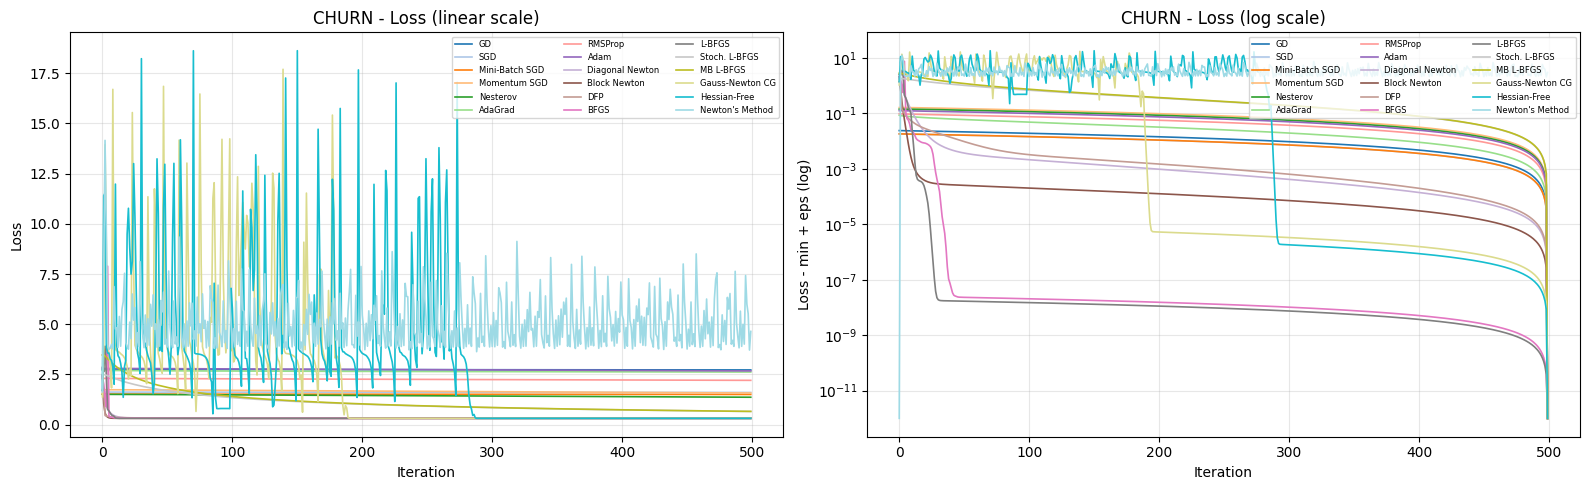

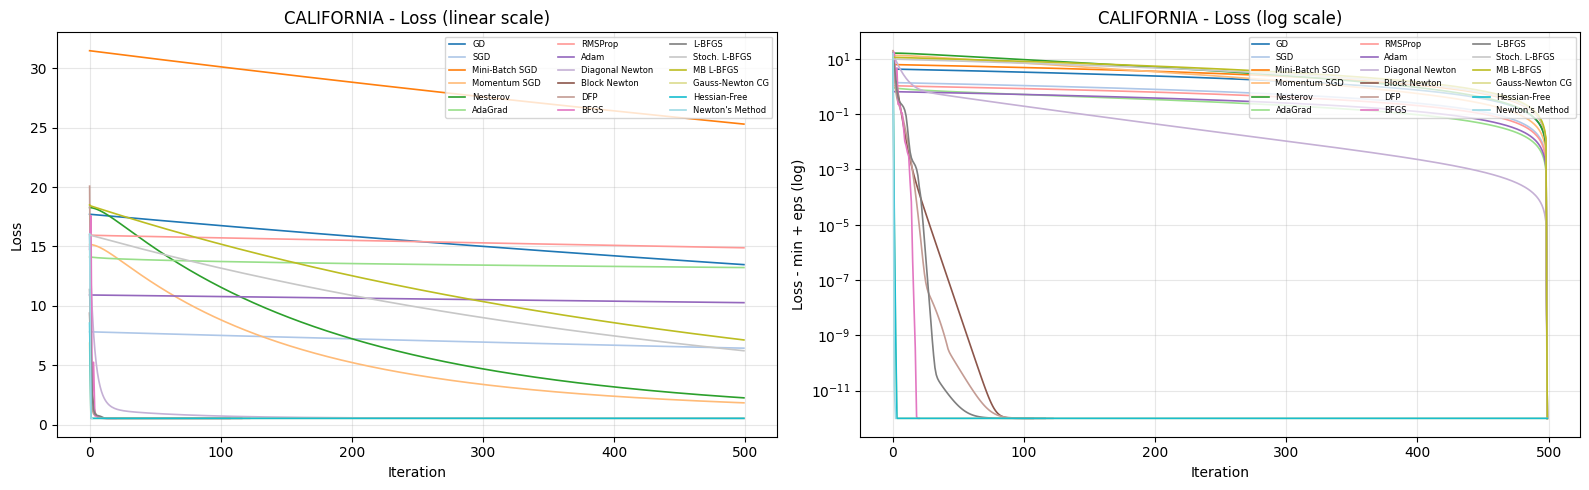

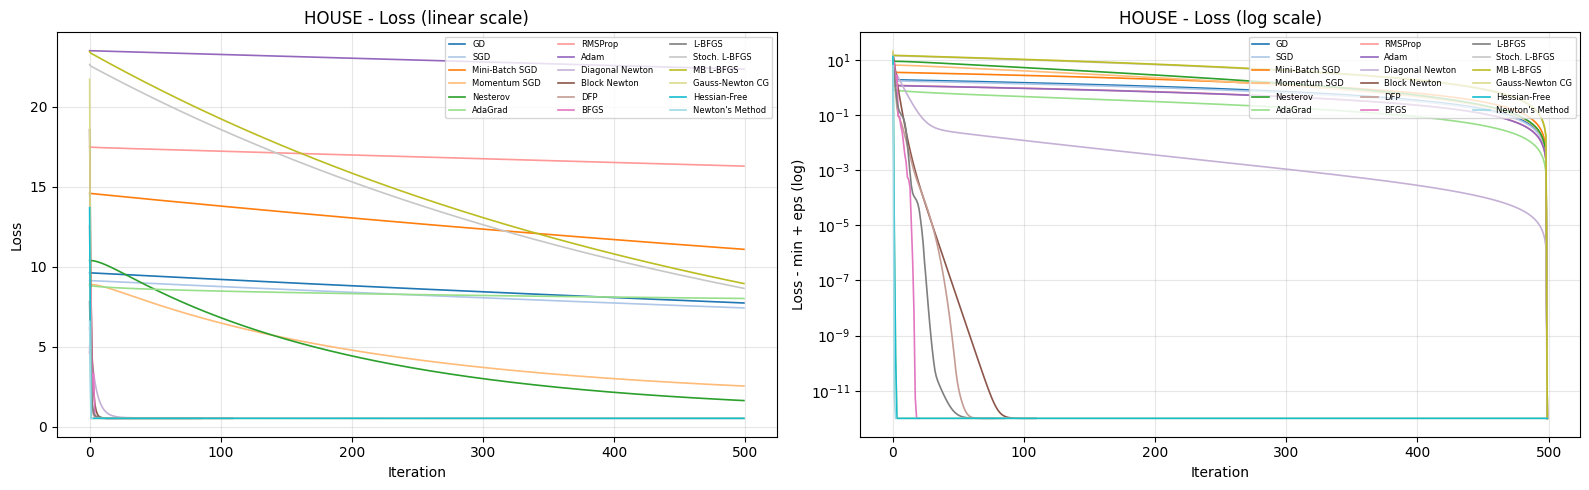

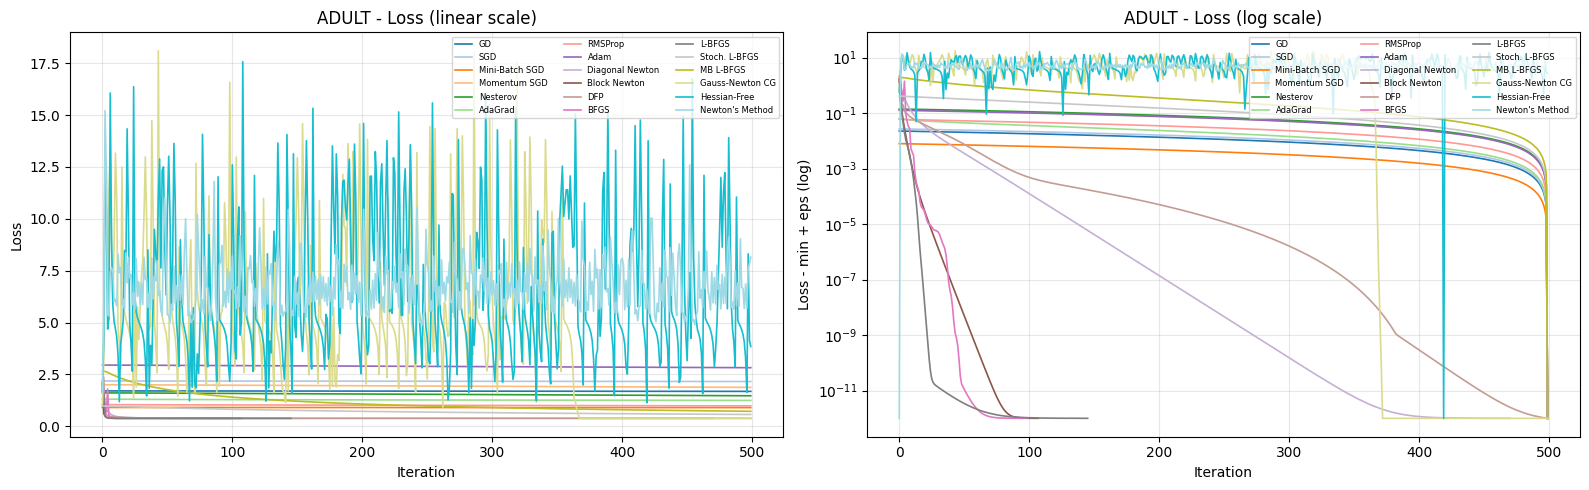

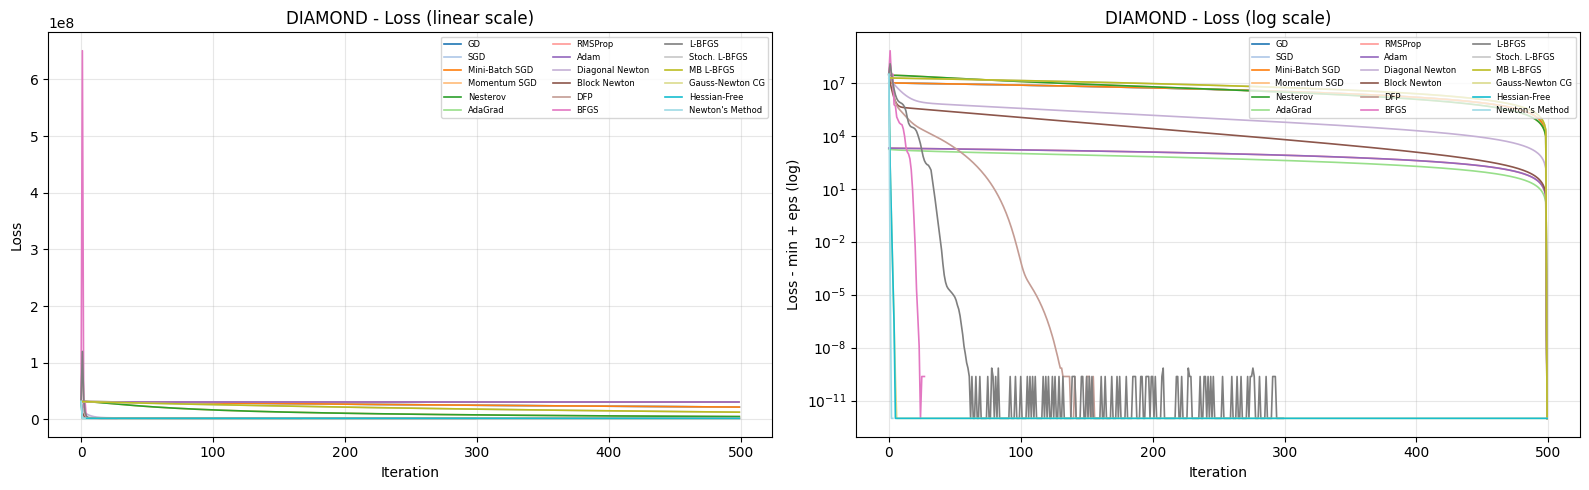

In [95]:
for ds_name, task, *_ in DATASETS:
    plot_loss_curves_ds(ds_name, all_results[ds_name])

## 6. Gradient Norm Curves per Dataset

In [96]:
def plot_grad_norm_ds(ds_name, ds_results, max_show=18):
    fig, ax = plt.subplots(figsize=(12, 5))
    labels = [l for l in ds_results if ds_results[l].get('logger') is not None][:max_show]
    colors = cm.tab20(np.linspace(0, 1, min(len(labels), 20)))
    for label, color in zip(labels, colors):
        logger = ds_results[label].get('logger')
        if logger is None:
            continue
        norms = logger.grad_norms()
        if norms:
            ax.semilogy(norms, label=label, color=color, linewidth=1.2)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('||grad|| (log scale)')
    ax.set_title(f'{ds_name} - Gradient Norm')
    ax.legend(fontsize=6, ncol=3, loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

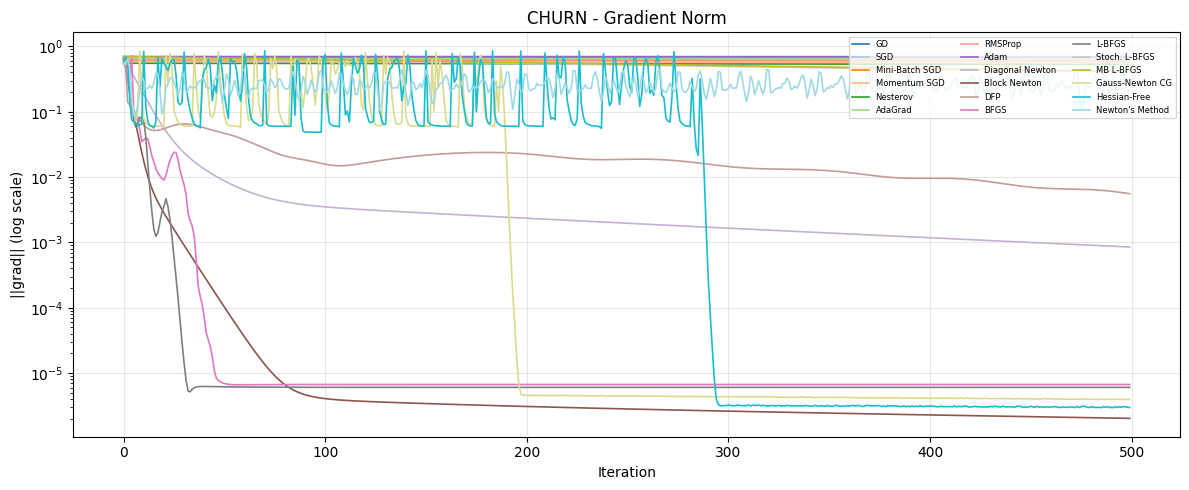

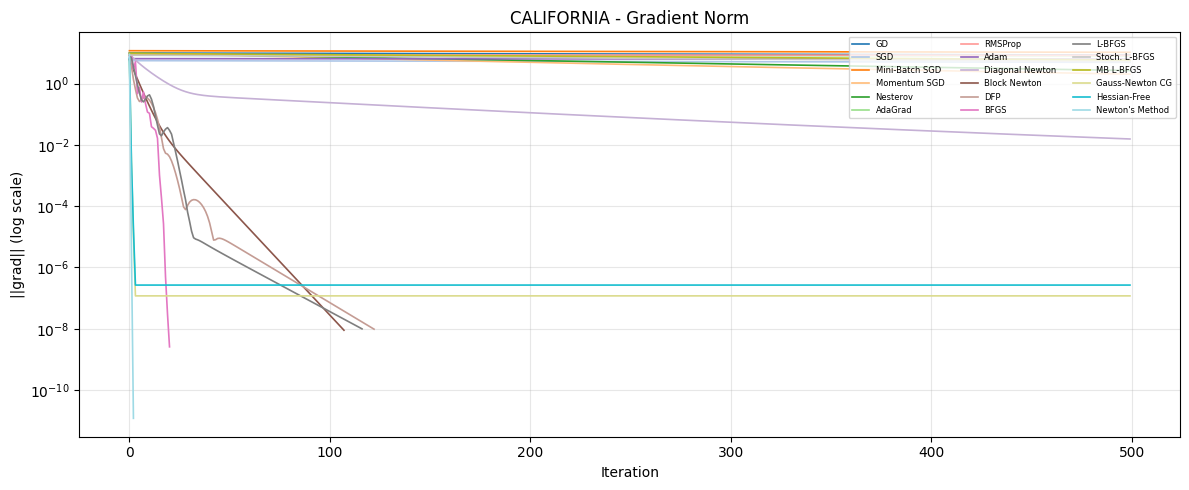

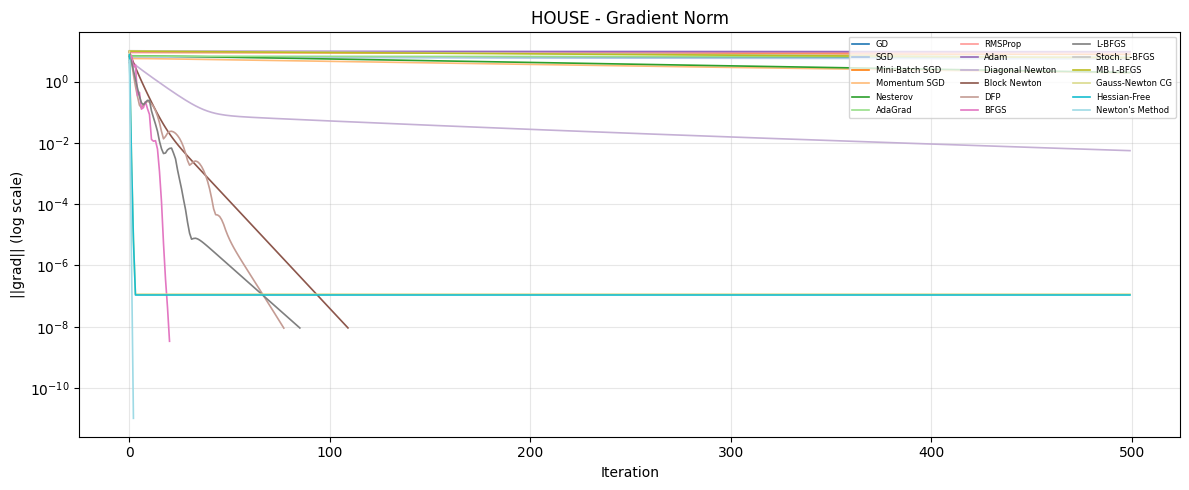

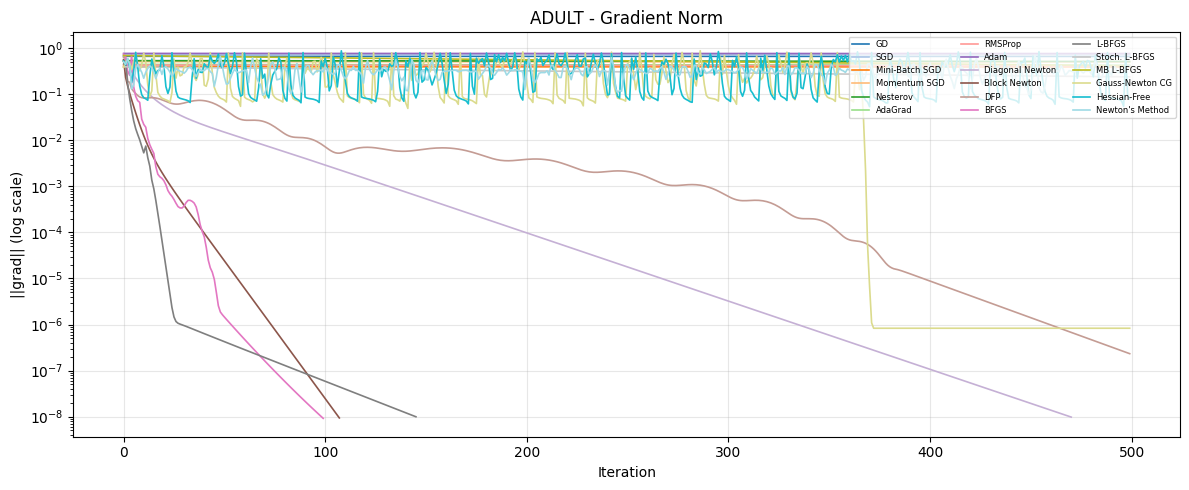

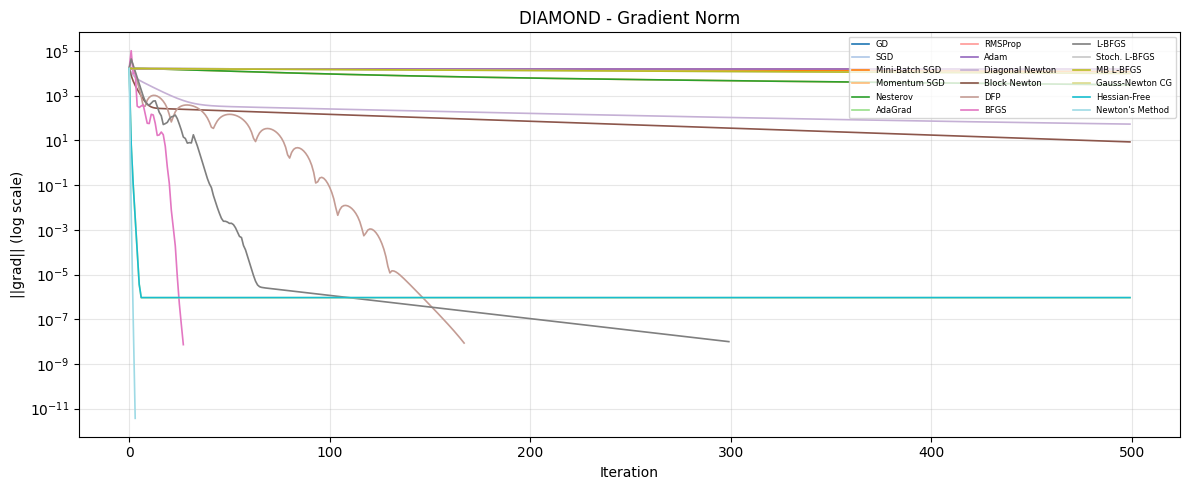

In [97]:
for ds_name, task, *_ in DATASETS:
    plot_grad_norm_ds(ds_name, all_results[ds_name])

## 7. Per-Dataset Summary Tables

In [98]:
def convergence_speed(logger, threshold=0.01):
    """Steps to reach threshold * initial_loss; returns max_iter if never reached."""
    losses = logger.losses()
    if not losses:
        return float('nan')
    target = losses[0] * threshold
    for i, l in enumerate(losses):
        if l <= target:
            return i
    return len(losses)


def build_ds_summary(ds_name, ds_results):
    rows = []
    for label, res in ds_results.items():
        logger = res.get('logger')
        task   = res.get('task', '')
        if logger is None:
            rows.append({'Optimizer': label, 'Steps': 0,
                         'Final Loss': float('nan'), 'Best Loss': float('nan'),
                         'Val Score': float('nan'), 'Conv Speed': float('nan'),
                         'Runtime (s)': 0.0,                         'Error': res.get('error', '')})
            continue
        score_col = 'Val Acc' if task == 'classification' else 'Val R2'
        rows.append({
            'Optimizer':      label,
            'Steps':          logger.n_steps(),
            'Final Loss':     round(logger.final_loss(), 6),
            'Best Loss':      round(logger.best_loss(), 6),
            score_col:        round(res.get('val_score', float('nan')), 4),
            'Conv Speed':     round(convergence_speed(logger), 4),
            'Runtime (s)':    round(res.get('runtime', float('nan')), 4),
        })
    df = pd.DataFrame(rows).sort_values('Final Loss').reset_index(drop=True)
    return df


In [99]:
ds_summary_dfs = {}
for ds_name, task, *_ in DATASETS:
    df = build_ds_summary(ds_name, all_results[ds_name])
    ds_summary_dfs[ds_name] = df
    print(f'\n=== {ds_name} ({task}) ===')
    display(df)


=== CHURN (classification) ===


,Optimizer,Steps,Final Loss,Best Loss,Val Acc,Conv Speed,Runtime (s)
0,Block Newton,500,0.313727,0.313727,0.8664,500,0.5359
1,Hessian-Free,500,0.314035,0.314035,0.8664,500,1.3351
2,Gauss-Newton CG,500,0.314042,0.314042,0.8664,500,0.6817
3,L-BFGS,500,0.314051,0.314051,0.8664,500,0.5848
4,BFGS,500,0.314061,0.314061,0.8664,500,0.4457
5,DFP,500,0.314148,0.314148,0.8648,500,0.4268
6,Diagonal Newton,500,0.314202,0.314202,0.8672,500,0.4355
7,Stoch. L-BFGS,500,0.657054,0.657054,0.6536,500,0.5374
8,MB L-BFGS,500,0.659091,0.659091,0.6712,500,0.6724
9,Nesterov,500,1.365223,1.365223,0.5928,500,0.3966



=== CALIFORNIA (regression) ===


,Optimizer,Steps,Final Loss,Best Loss,Val R2,Conv Speed,Runtime (s)
0,Newton's Method,3,0.520552,0.520552,0.5911,3,0.0021
1,Gauss-Newton CG,500,0.520552,0.520552,0.5911,500,0.4493
2,L-BFGS,117,0.520552,0.520552,0.5911,117,0.1132
3,BFGS,21,0.520552,0.520552,0.5911,21,0.0158
4,DFP,123,0.520552,0.520552,0.5911,123,0.0891
5,Block Newton,108,0.520552,0.520552,0.5911,108,0.1118
6,Hessian-Free,500,0.520552,0.520552,0.5911,500,0.3648
7,Diagonal Newton,500,0.521675,0.521675,0.5895,500,0.4131
8,Momentum SGD,500,1.826413,1.826413,-0.3476,500,0.3536
9,Nesterov,500,2.247224,2.247224,-0.8295,500,0.3149



=== HOUSE (regression) ===


,Optimizer,Steps,Final Loss,Best Loss,Val R2,Conv Speed,Runtime (s)
0,Newton's Method,3,0.520552,0.520552,0.5911,3,0.0025
1,Gauss-Newton CG,500,0.520552,0.520552,0.5911,500,0.3582
2,L-BFGS,86,0.520552,0.520552,0.5911,86,0.0722
3,BFGS,21,0.520552,0.520552,0.5911,21,0.0147
4,DFP,78,0.520552,0.520552,0.5911,78,0.0527
5,Block Newton,110,0.520552,0.520552,0.5911,110,0.0977
6,Hessian-Free,500,0.520552,0.520552,0.5911,500,0.4202
7,Diagonal Newton,500,0.520722,0.520722,0.5924,500,0.4258
8,Nesterov,500,1.630390,1.630390,-0.4476,500,0.3299
9,Momentum SGD,500,2.539984,2.539984,-1.1534,500,0.3466



=== ADULT (classification) ===


,Optimizer,Steps,Final Loss,Best Loss,Val Acc,Conv Speed,Runtime (s)
0,Diagonal Newton,471,0.382430,0.382430,0.8284,471,1.8173
1,Gauss-Newton CG,500,0.382430,0.382430,0.8284,500,2.3568
2,L-BFGS,146,0.382430,0.382430,0.8284,146,0.4547
3,Block Newton,108,0.382430,0.382430,0.8284,108,0.4382
4,DFP,500,0.382430,0.382430,0.8284,500,1.4428
5,BFGS,100,0.382430,0.382430,0.8284,100,0.3102
6,Stoch. L-BFGS,500,0.567939,0.567939,0.7111,500,1.9239
7,MB L-BFGS,500,0.721722,0.721722,0.5637,500,2.6344
8,Mini-Batch SGD,500,0.898714,0.898714,0.5840,500,1.8120
9,RMSProp,500,0.982432,0.982432,0.6706,500,1.5155



=== DIAMOND (regression) ===


,Optimizer,Steps,Final Loss,Best Loss,Val R2,Conv Speed,Runtime (s)
0,Newton's Method,4,1.841927e+06,1.841927e+06,0.8860,4,0.0059
1,Gauss-Newton CG,500,1.841927e+06,1.841927e+06,0.8860,500,0.7683
2,L-BFGS,300,1.841927e+06,1.841927e+06,0.8860,300,0.4047
3,BFGS,28,1.841927e+06,1.841927e+06,0.8860,28,0.0323
4,DFP,168,1.841927e+06,1.841927e+06,0.8860,168,0.1880
5,Hessian-Free,500,1.841927e+06,1.841927e+06,0.8860,500,0.5798
6,Block Newton,500,1.842305e+06,1.842305e+06,0.8859,500,0.7933
7,Diagonal Newton,500,1.877739e+06,1.877739e+06,0.8834,500,0.7624
8,Momentum SGD,500,4.977490e+06,4.977490e+06,0.6936,500,0.6047
9,Nesterov,500,4.987378e+06,4.987378e+06,0.6930,500,0.6000


## 8. Cross-Dataset Summary Visualisations

The following plots reveal which optimizers generalise well across different data regimes.

In [100]:
def get_opt_labels():
    return [label for label, _ in make_optimizers(100)]


def build_cross_ds_matrix(metric_fn, clip_nan=1e6):
    opt_labels = get_opt_labels()
    ds_labels  = [ds_name for ds_name, *_ in DATASETS]
    mat = np.full((len(opt_labels), len(ds_labels)), np.nan)
    for j, ds_name in enumerate(ds_labels):
        for i, opt in enumerate(opt_labels):
            res = all_results[ds_name].get(opt, {})
            try:
                val = float(metric_fn(res))
            except Exception:
                val = np.nan
            mat[i, j] = clip_nan if not np.isfinite(val) else val
    return mat, opt_labels, ds_labels


def plot_cross_heatmap(mat, opt_labels, ds_labels, title, fmt='.4g',
                       cmap='RdYlGn_r', invert=False):
    fig, ax = plt.subplots(figsize=(max(10, len(ds_labels) * 1.2),
                                    max(6, len(opt_labels) * 0.5)))
    mat_norm = mat.copy().astype(float)
    for j in range(mat_norm.shape[1]):
        col = mat_norm[:, j]
        cmin, cmax = np.nanmin(col), np.nanmax(col)
        if cmax > cmin:
            mat_norm[:, j] = (col - cmin) / (cmax - cmin)
        else:
            mat_norm[:, j] = 0.0
    if invert:
        mat_norm = 1.0 - mat_norm
    im = ax.imshow(mat_norm, aspect='auto', cmap=cmap, vmin=0, vmax=1)
    ax.set_xticks(range(len(ds_labels)))
    ax.set_xticklabels(ds_labels, rotation=40, ha='right', fontsize=8)
    ax.set_yticks(range(len(opt_labels)))
    ax.set_yticklabels(opt_labels, fontsize=8)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            txt = f'{val:{fmt}}' if np.isfinite(val) else 'N/A'
            ax.text(j, i, txt, ha='center', va='center', fontsize=6,
                    color='white' if mat_norm[i, j] > 0.6 else 'black')
    plt.colorbar(im, ax=ax, label='Normalised rank (0=best, 1=worst)')
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()

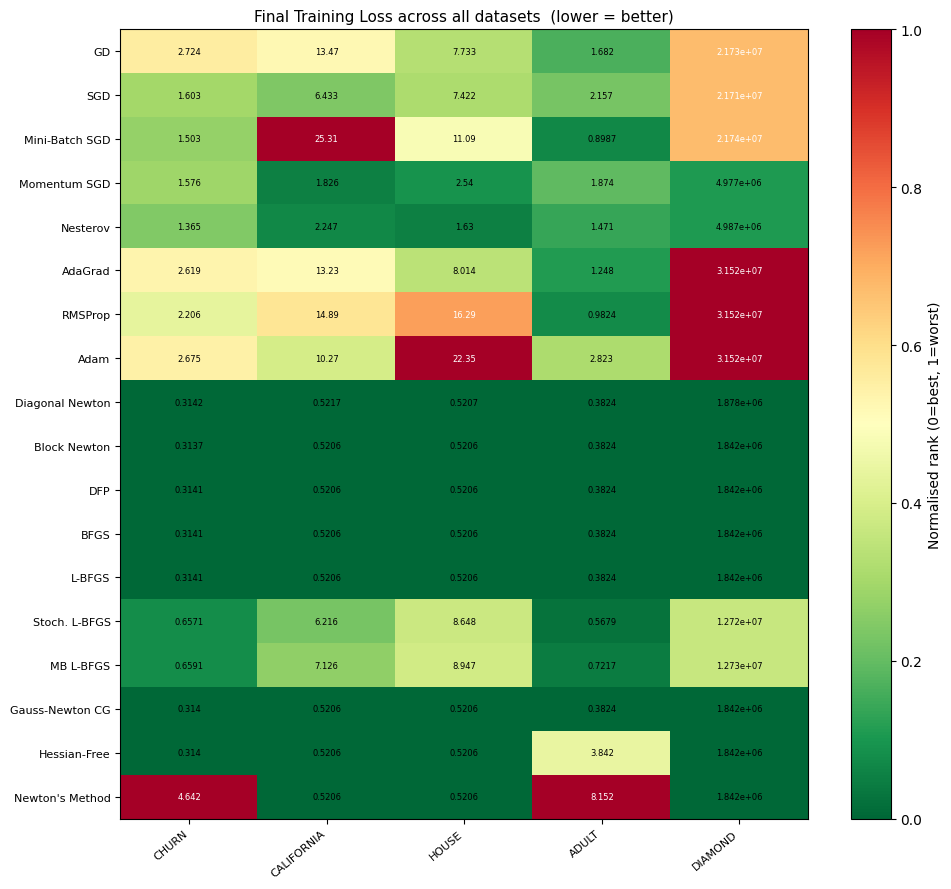

In [101]:
mat_fl, opt_labels, ds_labels = build_cross_ds_matrix(
    lambda r: r['logger'].final_loss() if r.get('logger') else float('nan')
)
plot_cross_heatmap(mat_fl, opt_labels, ds_labels,
                   title='Final Training Loss across all datasets  (lower = better)',
                   fmt='.4g', cmap='RdYlGn_r')

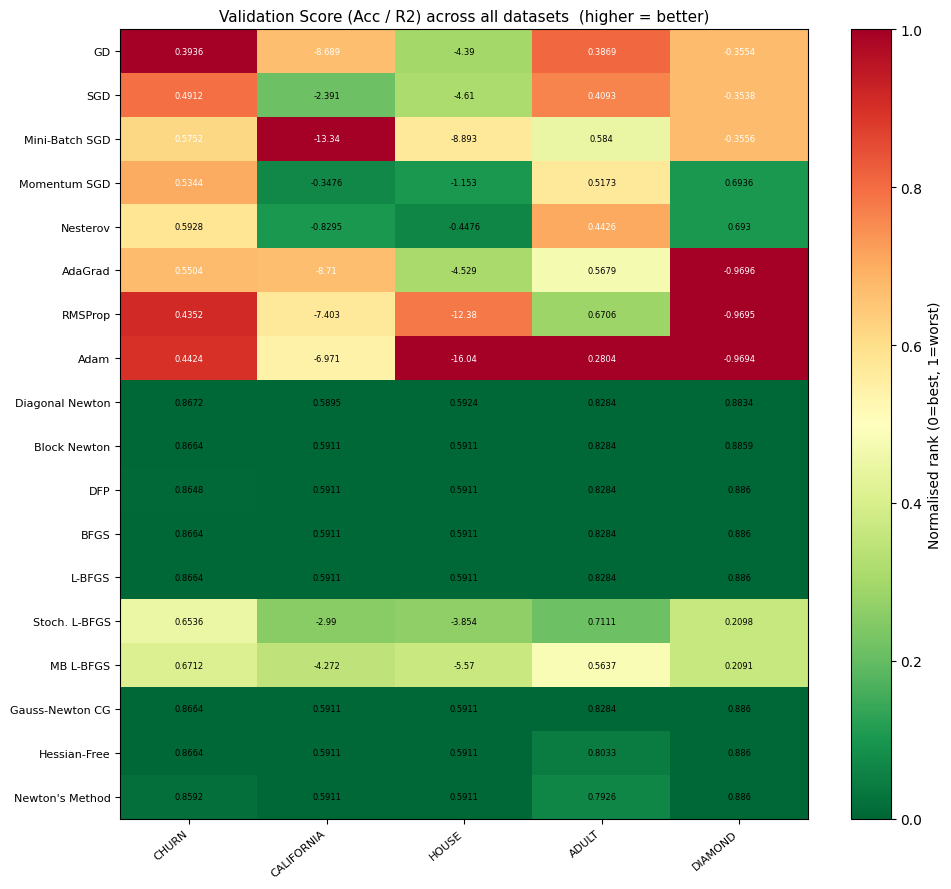

In [102]:
mat_vs, opt_labels, ds_labels = build_cross_ds_matrix(
    lambda r: r.get('val_score', float('nan'))
)
plot_cross_heatmap(mat_vs, opt_labels, ds_labels,
                   title='Validation Score (Acc / R2) across all datasets  (higher = better)',
                   fmt='.4g', cmap='RdYlGn_r', invert=True)

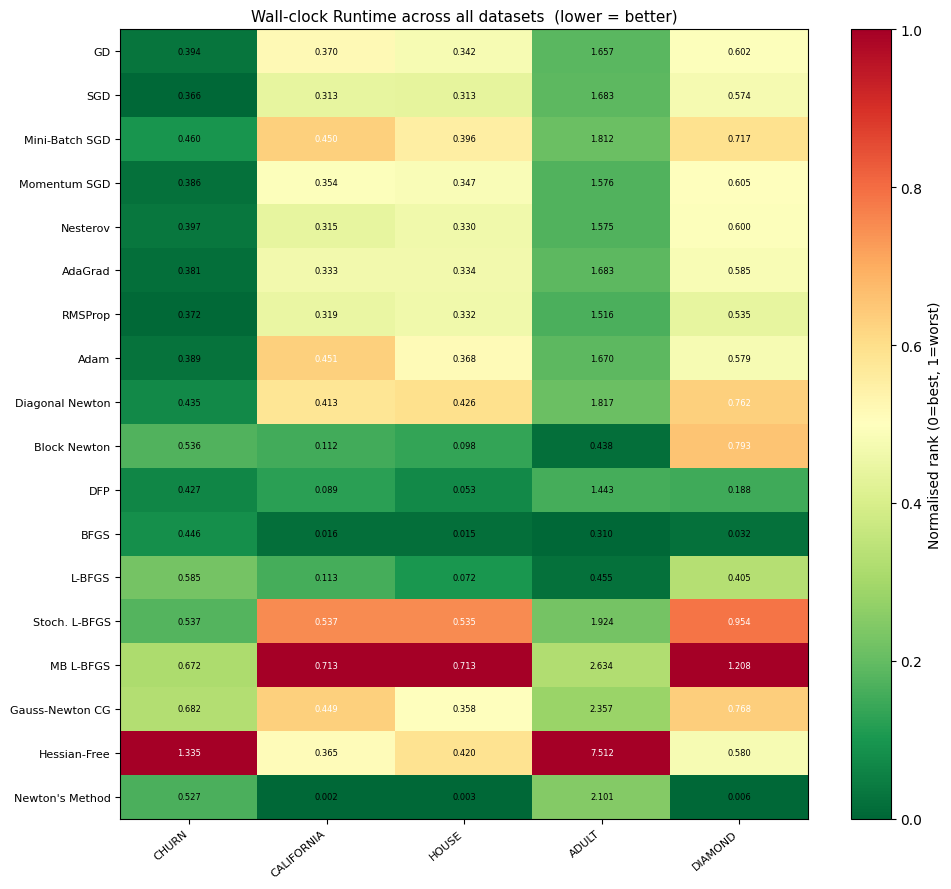

In [103]:
mat_rt, opt_labels, ds_labels = build_cross_ds_matrix(
    lambda r: r.get('runtime', float('nan'))
)
plot_cross_heatmap(mat_rt, opt_labels, ds_labels,
                   title='Wall-clock Runtime across all datasets  (lower = better)',
                   fmt='.3f', cmap='RdYlGn_r')

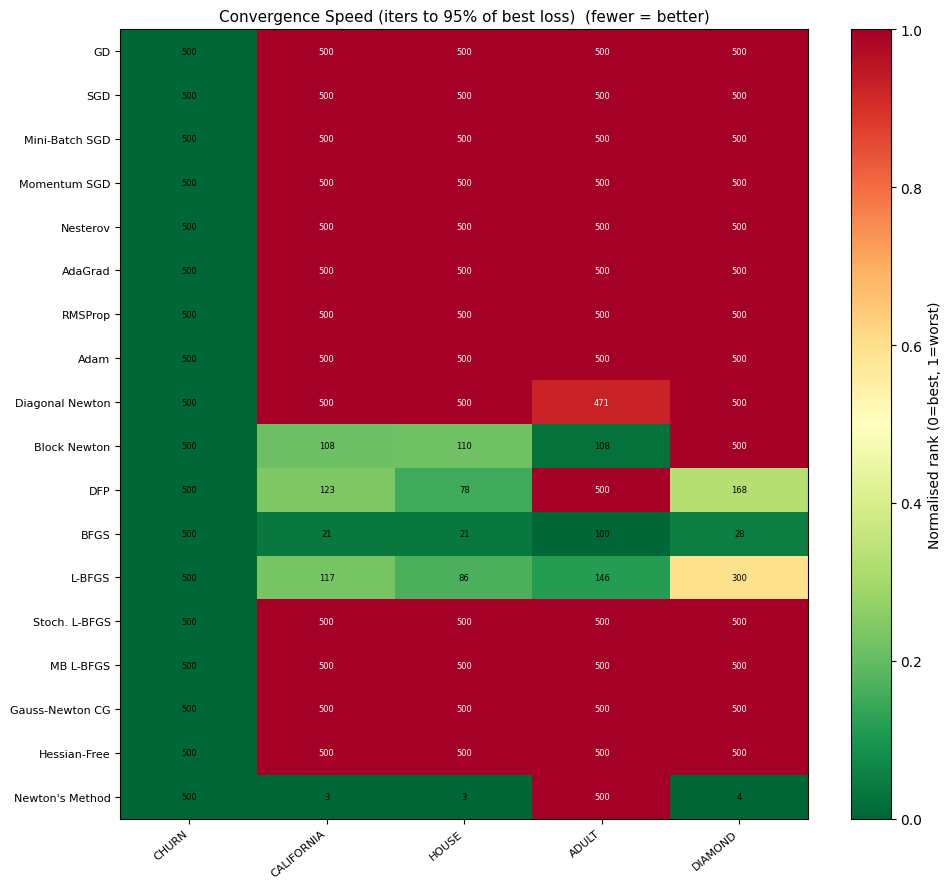

In [104]:
mat_cs, opt_labels, ds_labels = build_cross_ds_matrix(
    lambda r: convergence_speed(r['logger']) if r.get('logger') else float('nan')
)
plot_cross_heatmap(mat_cs, opt_labels, ds_labels,
                   title='Convergence Speed (iters to 95% of best loss)  (fewer = better)',
                   fmt='.0f', cmap='RdYlGn_r')

## 9. Final Loss Bar Charts per Dataset

In [105]:
def plot_final_loss_bar(ds_name, ds_results):
    labels = []
    final_losses = []
    for label, res in ds_results.items():
        logger = res.get('logger')
        if logger is None or not logger.losses():
            continue
        labels.append(label)
        final_losses.append(logger.final_loss())
    order = np.argsort(final_losses)
    labels = [labels[i] for i in order]
    final_losses = [final_losses[i] for i in order]
    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.barh(labels, final_losses,
                   color=cm.RdYlGn_r(np.linspace(0.1, 0.9, len(labels))))
    ax.set_xlabel('Final Loss')
    ax.set_title(f'{ds_name} - Final Loss (lower is better)')
    ax.grid(True, axis='x', alpha=0.3)
    for bar, val in zip(bars, final_losses):
        ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

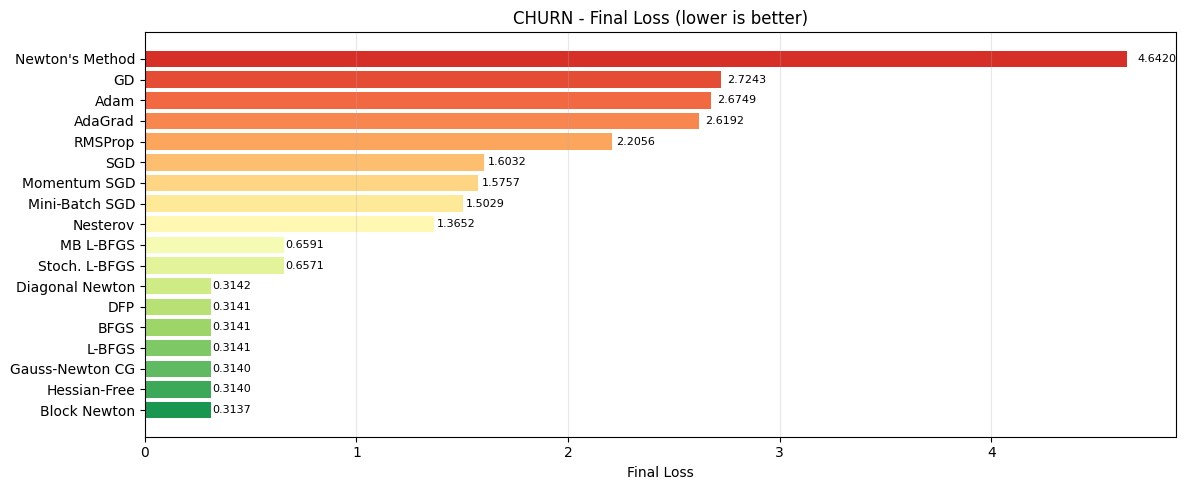

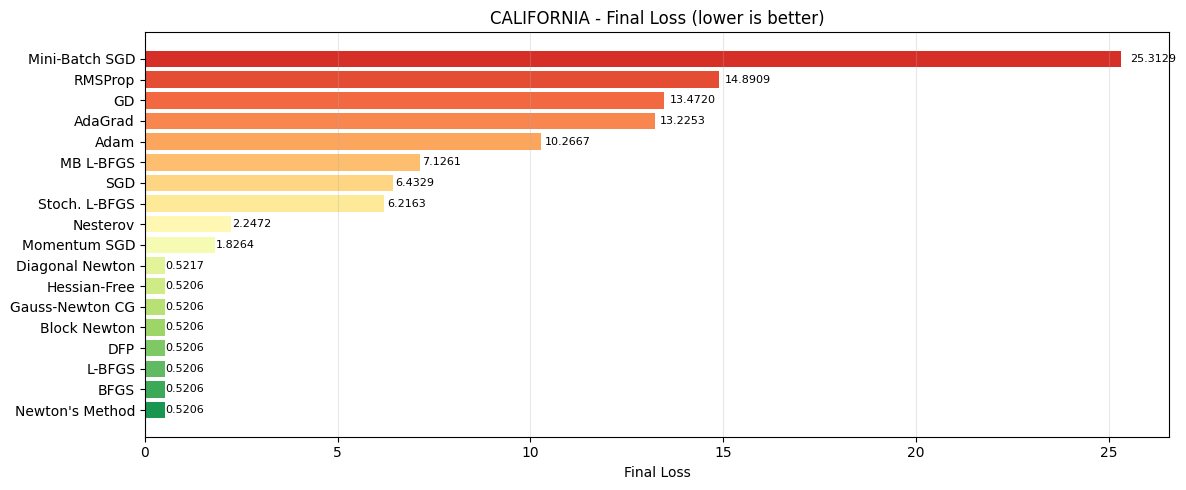

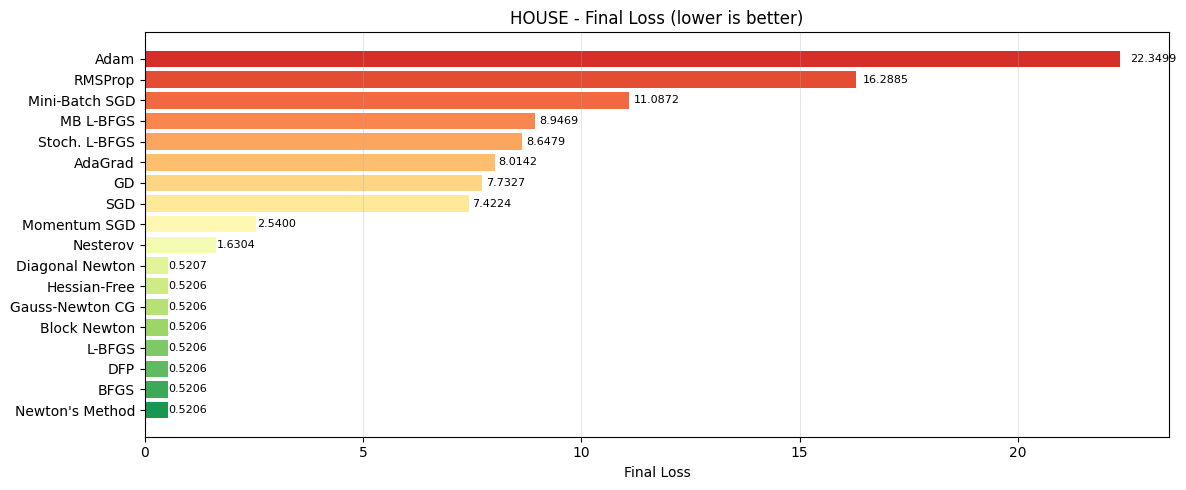

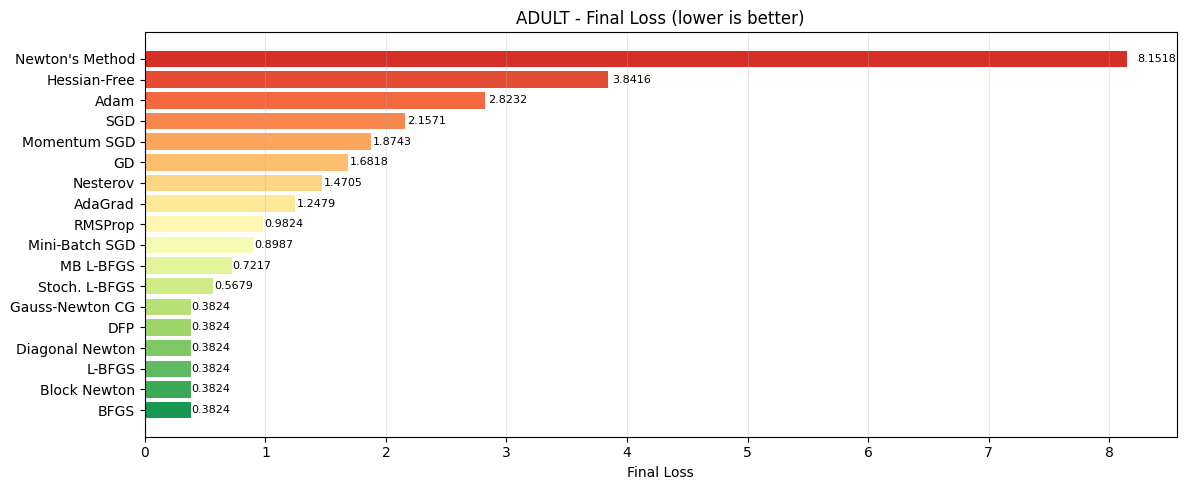

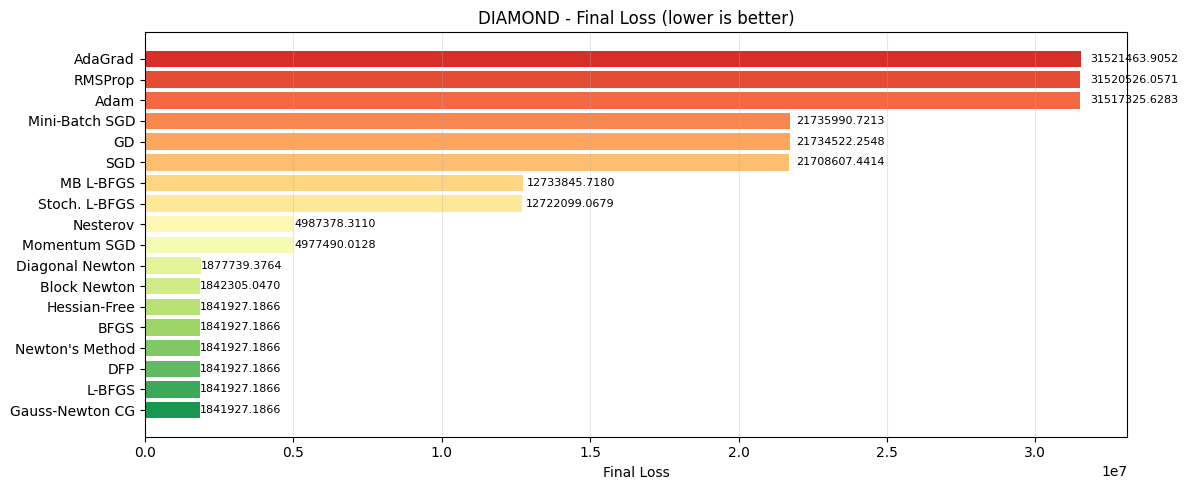

In [106]:
for ds_name, task, *_ in DATASETS:
    plot_final_loss_bar(ds_name, all_results[ds_name])

## 10. Time vs. Final Loss Scatter per Dataset

In [107]:
def plot_time_vs_loss(ds_name, ds_results):
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = cm.tab20(np.linspace(0, 1, len(ds_results)))
    for (label, res), color in zip(ds_results.items(), colors):
        logger = res.get('logger')
        if logger is None or not logger.losses():
            continue
        ax.scatter(res['runtime'], logger.final_loss(), color=color, s=80, zorder=3)
        ax.annotate(label, (res['runtime'], logger.final_loss()),
                    fontsize=7, xytext=(4, 4), textcoords='offset points')
    ax.set_xlabel('Wall-clock time (s)')
    ax.set_ylabel('Final Loss')
    ax.set_title(f'{ds_name} - Time vs. Final Loss')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

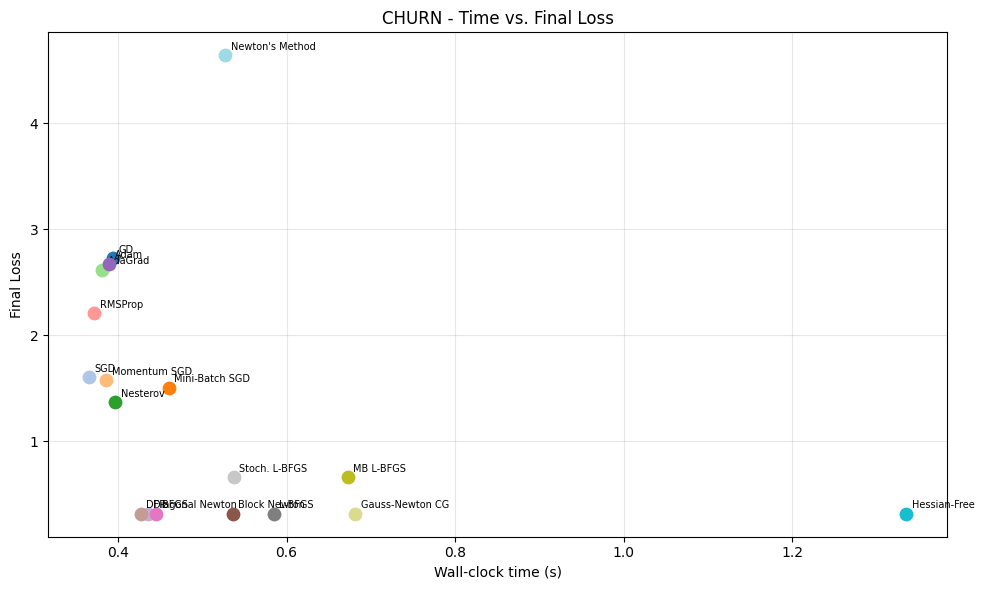

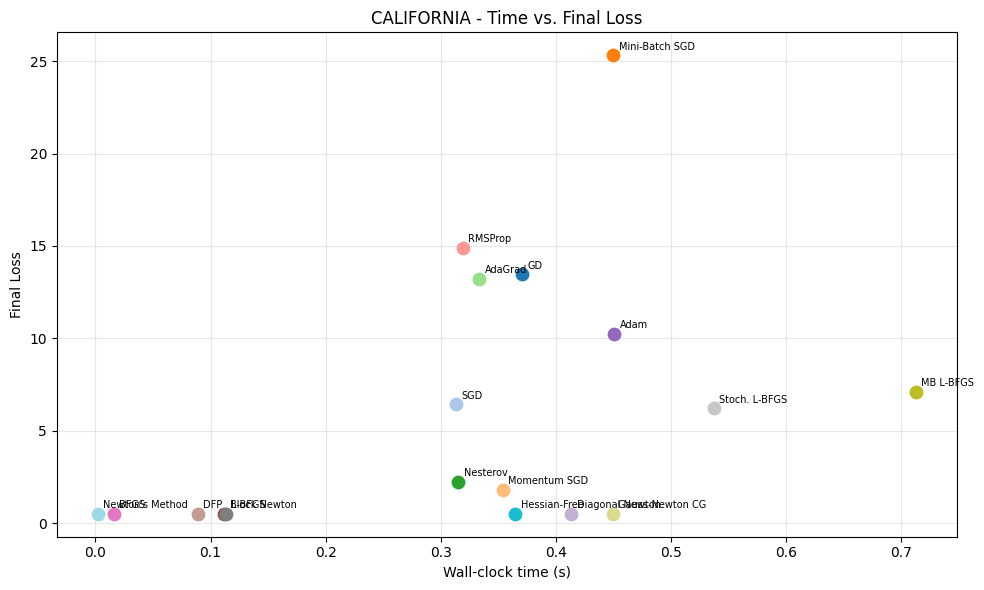

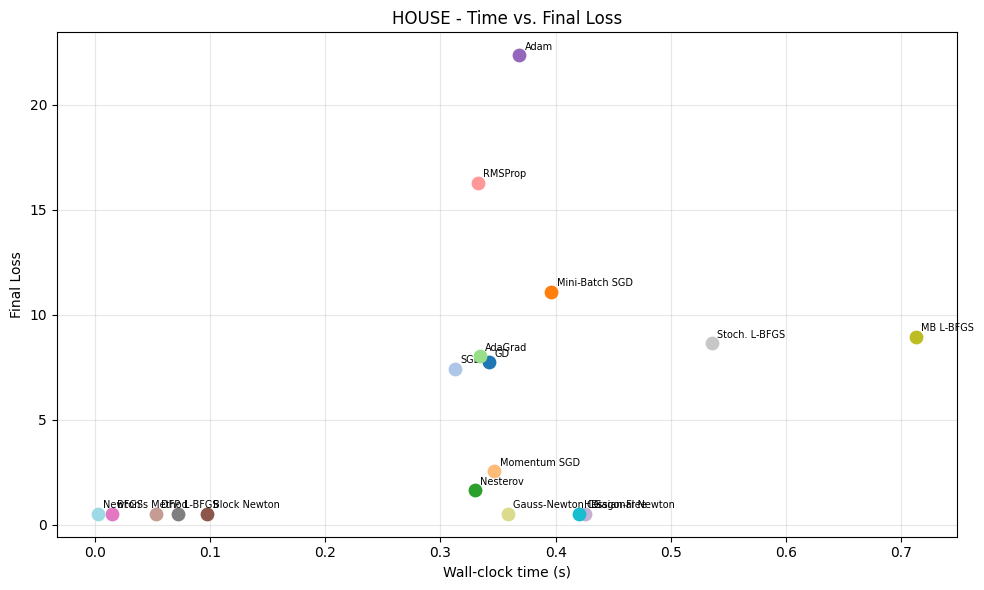

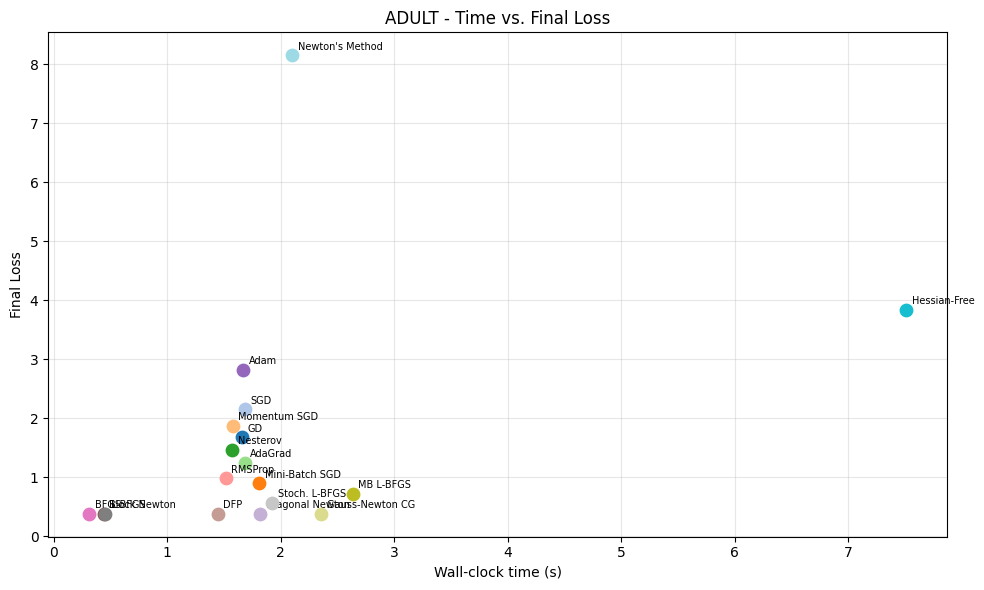

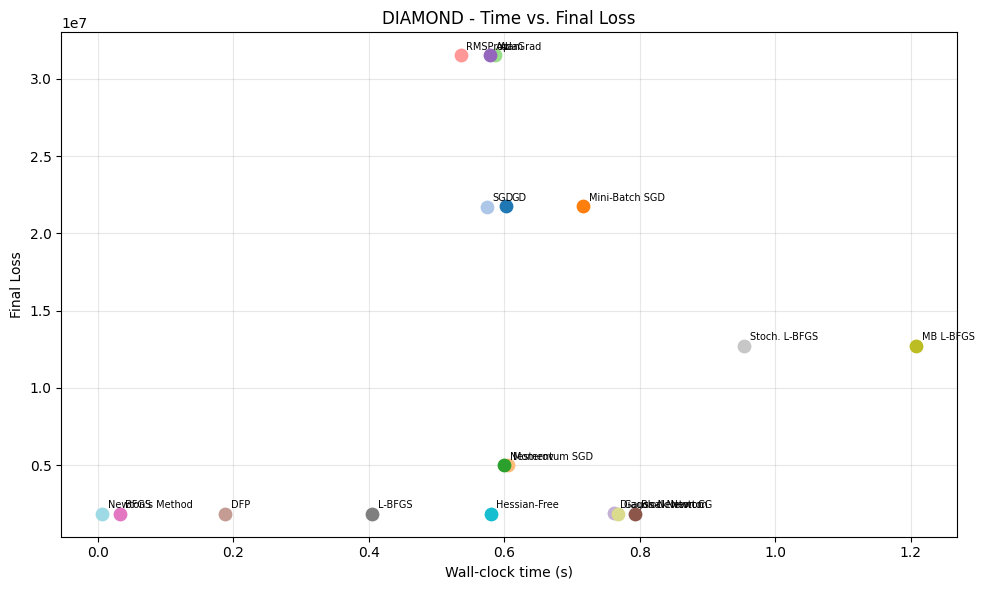

In [108]:
for ds_name, task, *_ in DATASETS:
    plot_time_vs_loss(ds_name, all_results[ds_name])

## 11. Overall Optimizer Ranking Across All Datasets

In [109]:
from scipy.stats import rankdata

opt_labels = get_opt_labels()
ds_labels  = [ds_name for ds_name, *_ in DATASETS]

rank_dfs = []
for metric_fn, metric_name, invert in [
    (lambda r: r['logger'].final_loss() if r.get('logger') else float('nan'),
     'Final Loss', False),
    (lambda r: r.get('val_score', float('nan')),
     'Val Score', True),
    (lambda r: r.get('runtime', float('nan')),
     'Runtime', False),
    (lambda r: convergence_speed(r['logger']) if r.get('logger') else float('nan'),
     'Conv Speed', False),
]:
    mat, _, _ = build_cross_ds_matrix(metric_fn)
    rank_mat = np.zeros_like(mat)
    for j in range(mat.shape[1]):
        col = mat[:, j].copy()
        if invert:
            col = -col
        rank_mat[:, j] = rankdata(col, method='average')
    mean_rank = rank_mat.mean(axis=1)
    rank_dfs.append(pd.Series(mean_rank, index=opt_labels, name=metric_name))

rank_df = pd.concat(rank_dfs, axis=1)
rank_df['Mean Rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('Mean Rank')
print('=== Overall Optimizer Ranking (lower mean rank = better) ===')
display(rank_df.round(2))

=== Overall Optimizer Ranking (lower mean rank = better) ===


,Final Loss,Val Score,Runtime,Conv Speed,Mean Rank
BFGS,2.9,4.9,3.4,3.3,3.62
DFP,3.8,4.1,4.2,6.4,4.62
L-BFGS,3.5,4.9,6.2,4.9,4.88
Block Newton,3.7,4.9,8.0,6.2,5.70
Newton's Method,8.9,6.0,6.0,4.8,6.42
Gauss-Newton CG,4.6,2.7,14.8,11.3,8.35
Diagonal Newton,7.0,4.3,13.0,9.8,8.52
Hessian-Free,7.6,4.2,14.0,11.3,9.28
Nesterov,10.2,11.0,7.4,11.3,9.98
Momentum SGD,10.8,11.2,8.8,11.3,10.52


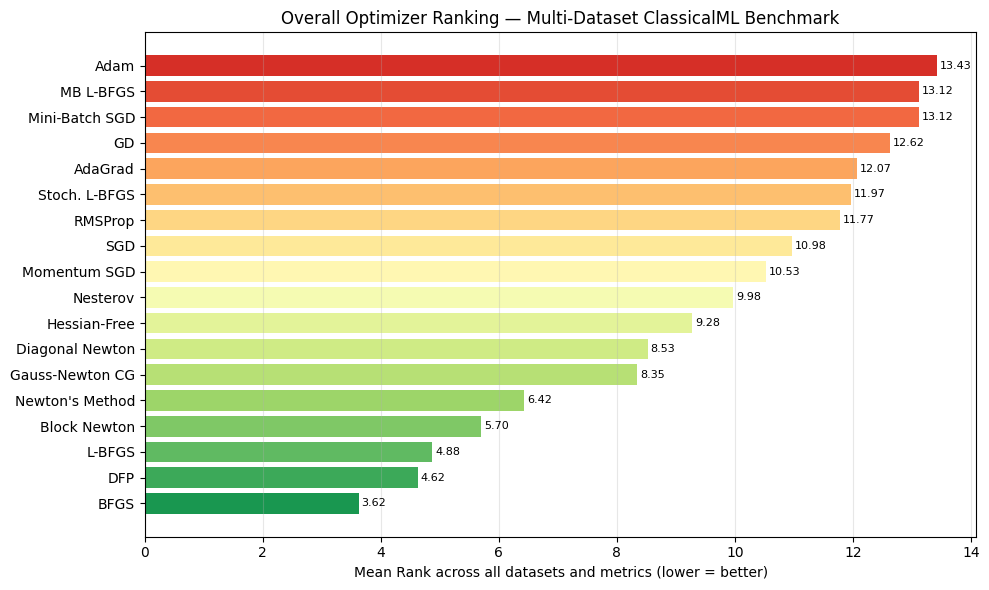

In [110]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = cm.RdYlGn_r(np.linspace(0.1, 0.9, len(rank_df)))
bars = ax.barh(rank_df.index, rank_df['Mean Rank'], color=colors)
ax.set_xlabel('Mean Rank across all datasets and metrics (lower = better)')
ax.set_title('Overall Optimizer Ranking — Multi-Dataset ClassicalML Benchmark')
ax.grid(True, axis='x', alpha=0.3)
for bar, val in zip(bars, rank_df['Mean Rank']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 12. Cross-Dataset Memory Heatmap

*(Memory profiling removed.)*

In [111]:
# Memory profiling removed
pass


In [112]:
# Memory profiling removed
pass
